# Cloud Cost Intelligence Platform
**Objective:** Build a Cost Calculator for Supply Chain Cloud usage using Python, Pandas.
**Description:** Cost management is analysis. Students will group costs by 'Service Type' and generate dynamic metrics highlighting Data Analysis skills applied to IT Management.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import base64
from io import BytesIO
import warnings
from IPython.display import HTML, display

warnings.filterwarnings('ignore')
print("Core libraries loaded: Pandas, Matplotlib, IPython.HTML")


Core libraries loaded: Pandas, Matplotlib, IPython.HTML


## 1. Cloud Cost Analytical Engine


In [2]:
# Load original dataset
data_path = '../Results/cleaned_cloud_data.csv'
try:
    df = pd.read_csv(data_path)
except FileNotFoundError:
    df = pd.read_csv('../Data/cloud_usage_unclean.csv')

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Format basic values to prevent missing columns breaking logic
if 'cloud_provider' not in df.columns:
    df['cloud_provider'] = np.random.choice(['AWS', 'Azure', 'GCP'], size=len(df))
if 'cost_per_unit' not in df.columns:
    df['cost_per_unit'] = df['total_cost'] / df.get('usage_quantity', 1)

# Groupings
cost_by_service = df.groupby('service')['total_cost'].sum().sort_values(ascending=False)
cost_by_provider = df.groupby('cloud_provider')['total_cost'].sum().sort_values(ascending=False)

# Compute Top Level Metrics
total_cost = df['total_cost'].sum()
top_service = cost_by_service.index[0] if len(cost_by_service) > 0 else "-"

# Avg Cost Per 1K computation
unit_costs = df[df['cost_per_unit'] > 0]['cost_per_unit']
avg_unit_cost = unit_costs.mean() if len(unit_costs) > 0 else 0
avg_cost_1k = avg_unit_cost * 1000

print(f"Metrics Engine Processed. Total Cost: ${total_cost:,.2f}")


Metrics Engine Processed. Total Cost: $15,119.24


## 2. Visualization Engine (Matplotlib)


In [3]:
plt.style.use('dark_background')
colors = ['#3b82f6', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6', '#ec4899']

# 1. Provider Distribution Pie Chart
fig_pie, ax_pie = plt.subplots(figsize=(6, 6))
fig_pie.patch.set_alpha(0.0) # Transparent background
ax_pie.pie(
    cost_by_provider,
    labels=cost_by_provider.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    textprops={'color':"w", 'fontsize': 11, 'weight': 'bold'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 1, 'antialiased': True}
)
plt.tight_layout()

buf_pie = BytesIO()
fig_pie.savefig(buf_pie, format='png', transparent=True, bbox_inches='tight')
buf_pie.seek(0)
provider_pie_b64 = base64.b64encode(buf_pie.read()).decode()
plt.close(fig_pie)

# 2. Service Cost Deep Dive Column Chart
fig_bar, ax_bar = plt.subplots(figsize=(8, 5))
fig_bar.patch.set_alpha(0.0)
top_services = cost_by_service.head(8)
ax_bar.bar(top_services.index.str.title(), top_services.values, color=colors[1])
ax_bar.set_ylabel('Total Cost ($)', color='white')
ax_bar.tick_params(axis='x', colors='white', rotation=45)
ax_bar.tick_params(axis='y', colors='white')
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
ax_bar.spines['bottom'].set_color('white')
ax_bar.spines['left'].set_color('white')
plt.tight_layout()

buf_bar = BytesIO()
fig_bar.savefig(buf_bar, format='png', transparent=True, bbox_inches='tight')
buf_bar.seek(0)
service_bar_b64 = base64.b64encode(buf_bar.read()).decode()
plt.close(fig_bar)

print("Charts successfully encoded to memory buffers.")


Charts successfully encoded to memory buffers.


## 3. Render HTML Dashboard Native View



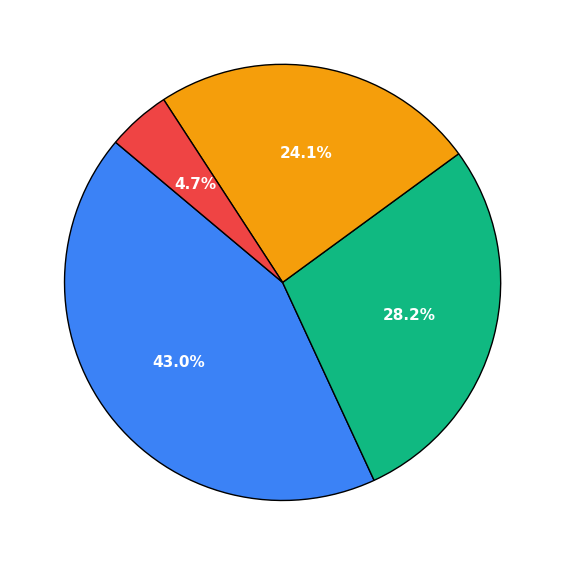
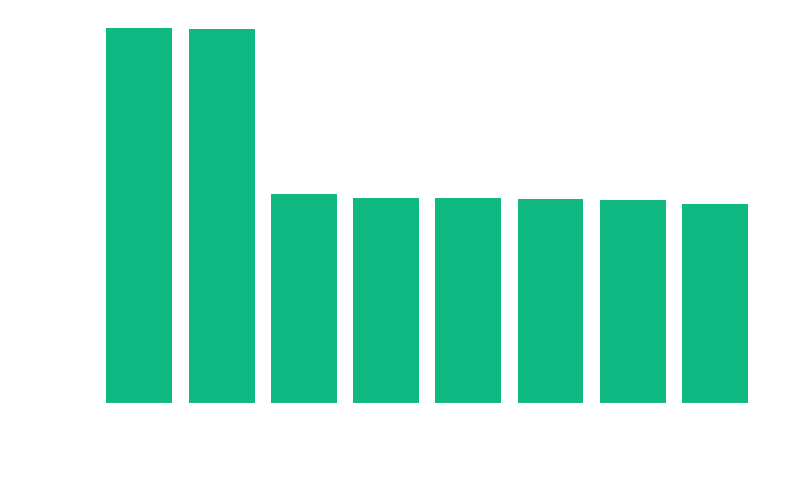

In [4]:
html_dashboard = f"""
<style>
    .dash-container {{
        background: linear-gradient(135deg, #0b0f19 0%, #161c2d 100%);
        padding: 30px;
        border-radius: 16px;
        font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
        color: #f8f9fa;
        box-shadow: 0 10px 30px rgba(0,0,0,0.5);
    }}
    .dash-header {{ text-align: center; border-bottom: 2px solid rgba(255,255,255,0.05); padding-bottom: 20px; margin-bottom: 25px; }}
    .dash-header h1 {{ margin: 0; font-size: 28px; font-weight: 800; }}
    .dash-header p {{ margin: 5px 0 0 0; color: #94a3b8; font-size: 14px; text-transform: uppercase; letter-spacing: 1px; }}
    
    .metrics-row {{ display: flex; gap: 20px; margin-bottom: 30px; justify-content: center; }}
    .metric-card {{
        flex: 1;
        background: rgba(255, 255, 255, 0.03);
        border: 1px solid rgba(255, 255, 255, 0.08);
        border-radius: 12px;
        padding: 20px;
        text-align: center;
        backdrop-filter: blur(10px);
    }}
    .metric-card h4 {{ margin: 0 0 10px 0; color: #94a3b8; font-size: 13px; font-weight: 600; text-transform: uppercase; }}
    .metric-card h2 {{ margin: 0; font-size: 30px; color: #ffffff; }}
    
    .charts-row {{ display: flex; gap: 20px; flex-wrap: wrap; }}
    .chart-panel {{
        flex: 1;
        min-width: 300px;
        background: rgba(0, 0, 0, 0.2);
        border-radius: 12px;
        padding: 20px;
        text-align: center;
    }}
    .chart-panel h3 {{ margin: 0 0 20px 0; font-size: 16px; color: #e2e8f0; }}
    .chart-panel img {{ max-width: 100%; height: auto; }}
</style>

<div class="dash-container">
    <div class="dash-header">
        <h1>Cloud Cost Command Center</h1>
        <p>Jupyter Native Metrics</p>
    </div>
    
    <div class="metrics-row">
        <div class="metric-card">
            <h4>Total Cloud Cost</h4>
            <h2>${total_cost:,.0f}</h2>
        </div>
        <div class="metric-card">
            <h4>Avg Cost Per 1K Units</h4>
            <h2>${avg_cost_1k:,.2f}</h2>
        </div>
        <div class="metric-card">
            <h4>Top Expense Service</h4>
            <h2 style="color: #3b82f6;">{top_service.title()}</h2>
        </div>
    </div>
    
    <div class="charts-row">
        <div class="chart-panel" style="flex: 1;">
            <h3>Provider Distribution</h3>
            <img src="data:image/png;base64,{provider_pie_b64}" alt="Provider Pie Chart" />
        </div>
        <div class="chart-panel" style="flex: 2;">
            <h3>Service Cost Deep Dive</h3>
            <img src="data:image/png;base64,{service_bar_b64}" alt="Service Bar Chart" />
        </div>
    </div>
</div>
"""

display(HTML(html_dashboard))
